# Лабораторна робота № 1

## Вхідний аналіз набору даних

**Дисципліна:** Інтелектуальний аналіз та візуалізація даних (СК26)
**Тривалість:** 2 год аудиторно + 3 год самостійної роботи · **Максимальна оцінка:** 4 бали

---

### Мета роботи

Пригадати роботу в Jupyter Notebook, бібліотеці `pandas` та побудову графіків —
і зробити це не на навчальному прикладі, а на реальному файлі, який ніхто не готував
спеціально для вас.

Ця робота виконується **до першої лекції**. Нічого нового знати не потрібно: усе,
що знадобиться, ви вже проходили в попередніх курсах. Усі поняття, яких ви тут
торкнетеся мимохідь, отримають назви й пояснення на лекціях 3 і 4.

### Дані

Файл `20171129_FINAL_FINAL.xlsx`, аркуш `Sheet1` — спостереження космічної погоди
за 28 серпня — 22 вересня 2017 року, зібрані з трьох різних джерел.

Файл видається **як є**, рівно в тому вигляді, у якому його колись вивантажили.
Ніхто не приводив його до ладу, і саме в цьому сенс: справжні дані здебільшого
надходять саме такими.

### Що ви маєте зробити

| Етап | Зміст | Де |
|---|---|---|
| 1 | Розібратися, що взагалі лежить у файлі | аудиторно |
| 2 | Виділити три таблиці й привести їх до робочого вигляду | аудиторно |
| 3 | Скласти паспорт даних: що є, чого бракує, що виглядає дивно | аудиторно |
| 4 | Об'єднати три таблиці в одну | аудиторно |
| 5 | Побудувати п'ять графіків, кожен — відповідь на питання | аудиторно + самостійно |
| 6 | Порівняти два графіки одних і тих самих даних | самостійно |
| 7 | Записати три спостереження про дані | самостійно |
| 8 | Декларація про використання інструментів ШІ | самостійно |

### Що здається

1. Цей файл `.ipynb` із заповненими розв'язками. **Ноутбук має виконуватися згори
   донизу на чистому ядрі** (Kernel → Restart & Run All) без помилок — це перевіряється
   першою дією на захисті.
2. Файл `master_hourly.csv` — об'єднана таблиця з етапу 4.
3. Експорт ноутбука у HTML або PDF.
4. Заповнена декларація (етап 8). Без неї фінальна самоперевірка не проходить.

### Критерії оцінювання

| Бали | Що досягнуто |
|---|---|
| 0 | Дані не опрацьовано, графіки не побудовано або побудовано з грубими помилками |
| 1 | Таблиці прочитано й кілька графіків побудовано, але типи графіків не відповідають даним, дивних значень не помічено |
| 2 | Таблиці розібрано й об'єднано, графіки коректні та підписані, але висновків під ними немає або вони формальні |
| 4 | Усе вище виконано, знайдено й пояснено дивні значення, під кожним графіком є змістовний висновок про дані |

**Головне про оцінку:** бали ставляться не за наявність графіка, а за речення під ним.
Код, який нічого не пояснює, коштує двох балів з чотирьох.

---
## Нагадування про Jupyter

Якщо давно не працювали — три речі, які знадобляться сьогодні:

* `Shift+Enter` виконує клітинку, `Esc` `A` / `Esc` `B` додає клітинку вище / нижче,
  `Esc` `M` перетворює клітинку на текстову (Markdown), `Esc` `Y` — назад на код.
* **Порядок виконання має значення.** Якщо ви правили клітинки в довільному порядку,
  результат може залежати від історії запусків. Перед здачею обов'язково
  **Kernel → Restart & Run All** — так ви побачите ноутбук очима викладача.
* Текстові клітинки — не прикраса. Висновки пишуться в них, а не в коментарях до коду.

---
## Крок 0. Ваші дані та варіант

Заповніть три змінні й виконайте обидві клітинки. Друга надрукує **ваше
індивідуальне завдання** — воно відрізняється від завдання сусіда.

In [1]:
ПІБ = 'Корнілов Артем Сергійович'        # напр. 'Шевченко Тарас'
ГРУПА = 'ШШ-31'      # напр. 'КН-31'
ВАРІАНТ = 10     # ваш номер за списком групи

assert ПІБ and ГРУПА and ВАРІАНТ, 'Заповніть ПІБ, ГРУПУ та ВАРІАНТ'

In [2]:
# --- клітинку не редагувати: вона видає ваше персональне завдання ------------
ПОТОКИ = ['P>1', 'P>5', 'P>10', 'P>30', 'P>50', 'P>100', 'E>0.8', 'E>2.0']

ПАРИ = [('швидкість вітру', 'густина вітру'),
        ('швидкість вітру', 'потік P>10'),
        ('густина вітру', 'потік P>1'),
        ('радіопотік F10.7', 'потік P>10'),
        ('радіопотік F10.7', 'швидкість вітру'),
        ('потік E>0.8', 'потік P>10')]

АГРЕГАТИ = ['середнє', 'максимум', 'медіана', 'мінімум']

ПИТАННЯ = [
    'Скільки годин за все вікно ваш потік перевищував своє власне медіанне значення?',
    'У яку добу середнє значення вашого потоку було найбільшим? А найменшим?',
    'О котрій годині доби потік E>0.8 у середньому найбільший? Побудуйте графік середнього за годинами доби.',
    'Яка частка рядків об’єднаної таблиці має пропуск хоча б в одному стовпці?',
    'У який день радіопотік F10.7 був найбільшим і чи збігається цей день з піком вашого потоку?',
    'Порівняйте медіану вашого потоку за перший і за другий тиждень спостережень. У скільки разів вони відрізняються?',
    'Скільки годин поспіль тривала найдовша неперервна серія «активних» годин (група з етапу 4)?',
    'Який зі стовпців об’єднаної таблиці має найбільший розкид відносно власного середнього?',
    'Яку частку сумарного значення вашого потоку за все вікно дали 24 години навколо піку?',
    'Скільки різних діб потрапило у групу «активні» і скільки — у групу «дуже активні»?',
]

i = int(ВАРІАНТ)
завдання = {
    'ваш потік':                      ПОТОКИ[(i * 3 + 1) % 8],
    'ваша пара для графіка 3':        ' та '.join(ПАРИ[(i * 5 + 2) % 6]),
    'ваш агрегат для етапу 4':        АГРЕГАТИ[(i * 5 + 1) % 4],
    'ваше додаткове питання':         ПИТАННЯ[(i * 11 + 5) % 10],
}

print('ІНДИВІДУАЛЬНЕ ЗАВДАННЯ · %s, %s, варіант %d' % (ПІБ, ГРУПА, i))
print('=' * 78)
for k, v in завдання.items():
    print('%-28s %s' % (k + ':', v))

ІНДИВІДУАЛЬНЕ ЗАВДАННЯ · Корнілов Артем Сергійович, ШШ-31, варіант 10
ваш потік:                   E>2.0
ваша пара для графіка 3:     радіопотік F10.7 та швидкість вітру
ваш агрегат для етапу 4:     мінімум
ваше додаткове питання:      Порівняйте медіану вашого потоку за перший і за другий тиждень спостережень. У скільки разів вони відрізняються?


Далі за текстом **«ваш потік»** означає стовпець, названий у першому рядку завдання.

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option('display.width', 200)
pd.set_option('display.max_columns', 40)
plt.rcParams.update({'figure.dpi': 110, 'axes.spines.top': False,
                     'axes.spines.right': False, 'font.size': 9})

ФАЙЛ = '20171129_FINAL_FINAL.xlsx'

---
# Етап 1. Що взагалі лежить у файлі

Перше правило роботи з незнайомими даними: спершу подивитися, потім рахувати.

### Завдання 1.1
Спробуйте прочитати аркуш `Sheet1` звичайним способом — `pd.read_excel(ФАЙЛ)` —
і виведіть перші рядки та типи стовпців.

*Очікуваний результат: результат буде дивним. Подивіться на назви стовпців і на
те, які там типи даних. Поясніть у наступній клітинці, чому так вийшло.*

In [4]:
# ВАШ КОД
pd.read_excel(ФАЙЛ)

,Unnamed: 0,ftp://ftp.swpc.noaa.gov/pub/lists/particle/,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7,Unnamed: 8,Unnamed: 9,Unnamed: 10,Unnamed: 11,Unnamed: 12,Unnamed: 13,Unnamed: 14,Unnamed: 15,Unnamed: 16,Unnamed: 17,Unnamed: 18,Unnamed: 19,Unnamed: 20,Unnamed: 21,Unnamed: 22,Unnamed: 23,Unnamed: 24,Unnamed: 25,http://umtof.umd.edu/pm/crn/,Unnamed: 27,Unnamed: 28,Unnamed: 29,Unnamed: 30,Unnamed: 31
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,:Data_list: 20170901_Gs_part_5m.txt,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,SOHO CELIAS Proton Monitor,NaN,NaN,NaN,NaN,NaN
2,NaN,:Created: 2017 Sep 02 0011 UTC,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Solar Wind Parameters for Carrington Rotation ...,NaN,NaN,NaN,NaN,NaN
3,NaN,"# Prepared by the U.S. Dept. of Commerce, NOAA...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Proton speed [km/sec],NaN,NaN,NaN,NaN,NaN
4,NaN,# Please send comments and suggestions to SWPC...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Proton density [protons per cubic centimeter],NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7220,NaN,2017,9,21,2335,58017,84900,21.9,0.361,0.202,0.084,0.0717,0.0475,143000,32900,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7221,NaN,2017,9,21,2340,58017,85200,14.1,0.343,0.309,0.118,0.0679,0.0328,143000,32100,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7222,NaN,2017,9,21,2345,58017,85500,27.1,0.465,0.237,0.106,0.0593,0.0251,140000,32500,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7223,NaN,2017,9,21,2350,58017,85800,23.7,0.36,0.205,0.127,0.091,0.0363,140000,32700,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


**Відповідь 1.1:** *(чому звичайне читання дало саме такий результат)*

Зараз модуль pandas явно відображує таблицю так, як вона відформатована в самому файлі, перший рядок, автоматично взятий за назви місттить 2 посилання і пусті клітинки. З рештою клітинок так само. Таблиця була створена для перегляду людиною, тому не є строго відформатована, як того очікує pandas

### Завдання 1.2
Прочитайте аркуш ще раз, але **без заголовка**: `pd.read_excel(ФАЙЛ, header=None)`.
Виведіть його розмір і подивіться на перші 30 рядків.

In [5]:
# ВАШ КОД
RAW = pd.read_excel(ФАЙЛ, header=None)
print('Розмір:', ' ')
print(RAW.shape)
RAW.head(30)


Розмір:  
(7226, 32)


,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31
0,NaN,ftp://ftp.swpc.noaa.gov/pub/lists/particle/,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,http://umtof.umd.edu/pm/crn/,NaN,NaN,NaN,NaN,NaN
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,:Data_list: 20170901_Gs_part_5m.txt,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,SOHO CELIAS Proton Monitor,NaN,NaN,NaN,NaN,NaN
3,NaN,:Created: 2017 Sep 02 0011 UTC,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Solar Wind Parameters for Carrington Rotation ...,NaN,NaN,NaN,NaN,NaN
4,NaN,"# Prepared by the U.S. Dept. of Commerce, NOAA...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Proton speed [km/sec],NaN,NaN,NaN,NaN,NaN
5,NaN,# Please send comments and suggestions to SWPC...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Proton density [protons per cubic centimeter],NaN,NaN,NaN,NaN,NaN
6,NaN,#,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,NaN,# Label: P > 1 = Particles at >1 Mev,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"Measurement time (Year, Month, Day of Month, D...",NaN,NaN,NaN,NaN,NaN
8,NaN,# Label: P > 5 = Particles at >5 Mev,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,NaN,# Label: P >10 = Particles at >10 Mev,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Тепер стовпці замість того, щоб автоматично прийняти 1 рядок за назви просто мають номери. Таблиця так само невітформатована і містить пусті значення

### Завдання 1.3
Для кожного стовпця порахуйте, скільки в ньому заповнених клітинок
(`RAW.notna().sum()`), і виведіть результат.

*Очікуваний результат: 32 числа. Серед них будуть нулі та згустки великих значень.
За цими згустками видно, що в аркуші **не одна таблиця, а кілька**, вставлені поруч.*

**Питання:** скільки таблиць в аркуші і які стовпці займає кожна?

In [6]:
# ВАШ КОД
non_null_counts = RAW.notna().sum()

for col, count in non_null_counts.items():
    print(f"Col {col}: {count}")

Col 0: 0
Col 1: 7223
Col 2: 7202
Col 3: 7202
Col 4: 7202
Col 5: 7203
Col 6: 7203
Col 7: 7198
Col 8: 7198
Col 9: 7198
Col 10: 7198
Col 11: 7198
Col 12: 7198
Col 13: 7198
Col 14: 7198
Col 15: 0
Col 16: 32
Col 17: 26
Col 18: 26
Col 19: 26
Col 20: 0
Col 21: 0
Col 22: 0
Col 23: 0
Col 24: 601
Col 25: 601
Col 26: 608
Col 27: 602
Col 28: 602
Col 29: 602
Col 30: 602
Col 31: 602


**Відповідь 1.3:** *(скільки таблиць і які стовпці кожна займає)*

На аркуші знаходиться 3 таблиці. 1 таблиця займає стовпці 1-14(починаючи з 0). 2 таблиця займає стовпці 16-19. 3 таблиця займає стовпці 24-31
Автор розмістив їх з інтервалом в одну-кілька колонок одна від однієї.

### Завдання 1.4
Над кожною таблицею є кілька текстових рядків — це службовий опис від тих, хто дані
збирав. Виведіть їх і випишіть для кожної таблиці **джерело даних та одиниці
вимірювання**.

*Це найкорисніші п'ять хвилин роботи: жодної з цих відомостей у самій таблиці немає,
і без них ви не знатимете, у чому вимірюєте.*

In [7]:
# ВАШ КОД
print("=== ТАБЛИЦЯ 1 (стовпці 1-14) ===")
print("\n".join(RAW.iloc[:24, 1].dropna().astype(str)))

print("\n=== ТАБЛИЦЯ 2 (стовпці 16-19) ===")
print("\n".join(RAW.iloc[13:27, 16].dropna().astype(str)))

print("\n=== ТАБЛИЦЯ 3 (стовпці 24-31) ===")
print("\n".join(RAW.iloc[:8, 26].dropna().astype(str)))

=== ТАБЛИЦЯ 1 (стовпці 1-14) ===
ftp://ftp.swpc.noaa.gov/pub/lists/particle/
:Data_list: 20170901_Gs_part_5m.txt
:Created: 2017 Sep 02 0011 UTC
# Prepared by the U.S. Dept. of Commerce, NOAA, Space Weather Prediction Center
# Please send comments and suggestions to SWPC.Webmaster@noaa.gov 
# 
# Label: P > 1 = Particles at >1 Mev
# Label: P > 5 = Particles at >5 Mev
# Label: P >10 = Particles at >10 Mev
# Label: P >30 = Particles at >30 Mev
# Label: P >50 = Particles at >50 Mev
# Label: P>100 = Particles at >100 Mev
# Label: E>0.8 = Electrons at >0.8 Mev
# Label: E>2.0 = Electrons at >2.0 Mev
# Label: E>4.0 = Electrons at >4.0 Mev
# Units: Particles = Protons/cm2-s-sr
# Units: Electrons = Electrons/cm2-s-sr
# Source: GOES-15
# Location: W135
# Missing data: -1.00e+05
5-minute  GOES-15 Solar Particle and Electron Flux

=== ТАБЛИЦЯ 2 (стовпці 16-19) ===
ftp://ftp.swpc.noaa.gov/pub/indices/old_indices/2017Q3_DSD.txt
Product: Daily Solar Data         quar_DSD.txt
:Issued: 0825 UT 04 Oct 201

**Відповідь 1.4:**

| Таблиця | Джерело | Одиниці вимірювання |
|---|---|---|
| A |  U.S. Dept. of Commerce, NOAA, Space Weather Prediction Center | Protons/cm2-s-sr, Electrons/cm2-s-sr|
| B | U.S. Dept. of Commerce, NOAA, Space Weather Prediction Center | solar flux units |
| C | SOHO CELIAS Proton Monitor | km/sec, protons per cubic centimeter |


---
# Етап 2. Три таблиці в робочому вигляді

У файлі три таблиці. Ось що в них лежить — решту ви вже знайшли самі:

| Таблиця | Стовпці аркуша | Що це | Один рядок = |
|---|---|---|---|
| A | B–O | вимірювання із супутника GOES-15: потоки частинок різної енергії | 5 хвилин |
| B | Q–T | добовий показник сонячної активності F10.7 | доба |
| C | Y–AF | швидкість і густина сонячного вітру | година |

### Завдання 2.1
Виділіть кожну таблицю в окремий `DataFrame` — назвіть їх `A`, `B` і `C`.
Дайте стовпцям осмислені назви й перетворіть значення на числа
(`pd.to_numeric(..., errors='coerce')` стане в пригоді).

In [8]:
# ВАШ КОД
cols_A = [
    "Year",
    "Month",
    "Day",
    "HHMM",
    "Modified_Julian_Day",
    "Seconds_of_Day",
    "P_gt_1",
    "P_gt_5",
    "P_gt_10",
    "P_gt_30",
    "P_gt_50",
    "P_gt_100",
    "E_gt_0_8",
    "E_gt_2_0",
]

A = RAW.iloc[26:, 1:15].copy()
A.columns = cols_A
A = A.dropna(how="all").apply(pd.to_numeric, errors="coerce").reset_index(drop=True)

cols_B = [
    "Year",
    "Month",
    "Day",
    "Radio_Flux_10_7"
]

B = RAW.iloc[27:, 16:20].copy()
B.columns = cols_B
B = B.dropna(how="all").apply(pd.to_numeric, errors="coerce").reset_index(drop=True)

cols_C = [
    "Year",
    "Month",
    "Day",
    "Hour",
    "Proton_Speed",
    "Proton_Density"
]

C = RAW.iloc[27:, 26:32].copy()
C.columns = cols_C
C = C.dropna(how="all").apply(pd.to_numeric, errors="coerce").reset_index(drop=True)

print(f"Розмір таблиці A: {A.shape}")
print(f"Розмір таблиці B: {B.shape}")
print(f"Розмір таблиці C: {C.shape}")

Розмір таблиці A: (7200, 14)
Розмір таблиці B: (25, 4)
Розмір таблиці C: (601, 6)


### Завдання 2.2
У кожній таблиці дата й час записані **по-різному** й розкидані по кількох стовпцях.
Зберіть для кожної таблиці один стовпець `ts` типу `datetime`.

Після цього обов'язково виведіть для кожної таблиці найранішу й найпізнішу дату.

*Очікуваний результат: усі три таблиці мають лежати в межах серпня–вересня 2017 року.
Якщо у вас вийшов інший рік — придивіться, як записано рік у тій таблиці, і виправте.*

In [9]:
# ВАШ КОД
hhmm_str = A["HHMM"].astype(int).astype(str).str.zfill(4)
A["ts"] = pd.to_datetime(
    A["Year"].astype(int).astype(str)
    + "-"
    + A["Month"].astype(int).astype(str).str.zfill(2)
    + "-"
    + A["Day"].astype(int).astype(str).str.zfill(2)
    + " "
    + hhmm_str.str[:2]
    + ":"
    + hhmm_str.str[2:]
)


B["ts"] = pd.to_datetime(
    B["Year"].astype(int).astype(str)
    + "-"
    + B["Month"].astype(int).astype(str).str.zfill(2)
    + "-"
    + B["Day"].astype(int).astype(str).str.zfill(2)
)


year_c = C["Year"].astype(int).apply(lambda y: y + 2000 if y < 100 else y)
C["ts"] = pd.to_datetime(
    year_c.astype(str)
    + "-"
    + C["Month"].astype(int).astype(str).str.zfill(2)
    + "-"
    + C["Day"].astype(int).astype(str).str.zfill(2)
    + " "
    + C["Hour"].astype(int).astype(str).str.zfill(2)
    + ":00:00"
)

print(f"Таблиця A: від {A['ts'].min()} до {A['ts'].max()}")
print(f"Таблиця B: від {B['ts'].min()} до {B['ts'].max()}")
print(f"Таблиця C: від {C['ts'].min()} до {C['ts'].max()}")

Таблиця A: від 2017-08-28 00:00:00 до 2017-09-21 23:55:00
Таблиця B: від 2017-08-28 00:00:00 до 2017-09-21 00:00:00
Таблиця C: від 2017-08-28 00:00:00 до 2017-09-22 00:00:00


**Самоперевірка етапу 2.** Клітинка має виконатися без помилок.

In [10]:
assert len(A) == 7200, 'у таблиці A має бути 7200 рядків, а є %d' % len(A)
assert len(B) == 25,   'у таблиці B має бути 25 рядків, а є %d' % len(B)
assert len(C) == 601,  'у таблиці C має бути 601 рядок, а є %d' % len(C)
for назва, т in [('A', A), ('B', B), ('C', C)]:
    рік = pd.to_datetime(т['ts']).dt.year
    assert рік.min() == 2017 and рік.max() == 2017, 'у таблиці %s рік не 2017 — перевірте збирання дати' % назва
print('Етап 2 пройдено')

Етап 2 пройдено


---
# Етап 3. Паспорт даних

### Завдання 3.1
Для кожної таблиці виведіть: розмір, типи стовпців, кількість пропусків у кожному
стовпці, кількість повних дублікатів рядків і описові статистики (`describe()`).

In [11]:
# ВАШ КОД
tables = {"Таблиця A": A, "Таблиця B": B, "Таблиця C": C}

for name, df in tables.items():
    print(f"{'='*30} {name} {'='*30}")
    print(f"1. Розмір (рядків, стовпців): {df.shape}")
    print(f"2. Кількість повних дублікатів рядків: {df.duplicated().sum()}")

    print("\n3. Типи даних та кількість пропусків (NaN):")
    info_df = pd.DataFrame(
        {"Dtype": df.dtypes, "Missing_Values": df.isna().sum()}
    )
    print(info_df)

    print("\n4. Описова статистика (describe):")
    display(df.describe(include="all"))
    print("\n")

============================== Таблиця A ==============================
1. Розмір (рядків, стовпців): (7200, 15)
2. Кількість повних дублікатів рядків: 0

3. Типи даних та кількість пропусків (NaN):
                              Dtype  Missing_Values
Year                          int64               0
Month                         int64               0
Day                           int64               0
HHMM                          int64               0
Modified_Julian_Day           int64               0
Seconds_of_Day                int64               0
P_gt_1                      float64               3
P_gt_5                      float64               3
P_gt_10                     float64               3
P_gt_30                     float64               3
P_gt_50                     float64               3
P_gt_100                    float64               3
E_gt_0_8                    float64               3
E_gt_2_0                    float64               3
ts                   

,Year,Month,Day,HHMM,Modified_Julian_Day,Seconds_of_Day,P_gt_1,P_gt_5,P_gt_10,P_gt_30,P_gt_50,P_gt_100,E_gt_0_8,E_gt_2_0,ts
count,7200.0,7200.000000,7200.000000,7200.000000,7200.000000,7200.000000,7197.000000,7197.000000,7197.000000,7197.000000,7197.000000,7197.00000,7197.000000,7197.000000,7200
mean,2017.0,8.840000,13.960000,1177.500000,58005.000000,43050.000000,689.325064,156.626057,76.474020,18.838604,7.446840,1.65929,81862.741801,11401.502123,2017-09-09 11:57:30
min,2017.0,8.000000,1.000000,0.000000,57993.000000,0.000000,0.429000,0.151000,0.117000,0.057600,0.045500,0.02240,4.300000,0.133000,2017-08-28 00:00:00
25%,2017.0,9.000000,7.000000,588.750000,57999.000000,21525.000000,11.700000,0.279000,0.186000,0.098400,0.059700,0.02630,22200.000000,552.000000,2017-09-03 05:58:45
50%,2017.0,9.000000,13.000000,1177.500000,58005.000000,43050.000000,55.400000,0.632000,0.376000,0.146000,0.086600,0.03630,68600.000000,4290.000000,2017-09-09 11:57:30
75%,2017.0,9.000000,19.000000,1766.250000,58011.000000,64575.000000,560.000000,107.000000,35.800000,0.990000,0.249000,0.06700,143000.000000,14100.000000,2017-09-15 17:56:15
max,2017.0,9.000000,31.000000,2355.000000,58017.000000,86100.000000,32500.000000,2890.000000,1330.000000,399.000000,191.000000,61.50000,259000.000000,110000.000000,2017-09-21 23:55:00
std,0.0,0.366632,8.775483,692.481902,7.211603,24943.113498,1625.968447,390.921861,222.362627,67.265595,28.620524,7.15889,65728.005824,16920.617446,NaN




============================== Таблиця B ==============================
1. Розмір (рядків, стовпців): (25, 5)
2. Кількість повних дублікатів рядків: 0

3. Типи даних та кількість пропусків (NaN):
                          Dtype  Missing_Values
Year                      int64               0
Month                     int64               0
Day                       int64               0
Radio_Flux_10_7           int64               0
ts               datetime64[ns]               0

4. Описова статистика (describe):


,Year,Month,Day,Radio_Flux_10_7,ts
count,25.0,25.000000,25.000000,25.000000,25
mean,2017.0,8.840000,13.960000,92.680000,2017-09-09 00:00:00
min,2017.0,8.000000,1.000000,71.000000,2017-08-28 00:00:00
25%,2017.0,9.000000,7.000000,74.000000,2017-09-03 00:00:00
50%,2017.0,9.000000,13.000000,84.000000,2017-09-09 00:00:00
75%,2017.0,9.000000,19.000000,107.000000,2017-09-15 00:00:00
max,2017.0,9.000000,31.000000,140.000000,2017-09-21 00:00:00
std,0.0,0.374166,8.955817,22.206831,NaN




============================== Таблиця C ==============================
1. Розмір (рядків, стовпців): (601, 7)
2. Кількість повних дублікатів рядків: 0

3. Типи даних та кількість пропусків (NaN):
                         Dtype  Missing_Values
Year                     int64               0
Month                    int64               0
Day                      int64               0
Hour                     int64               0
Proton_Speed             int64               0
Proton_Density         float64               0
ts              datetime64[ns]               0

4. Описова статистика (describe):


,Year,Month,Day,Hour,Proton_Speed,Proton_Density,ts
count,601.0,601.000000,601.000000,601.000000,601.000000,601.000000,601
mean,17.0,8.840266,13.973378,11.480865,506.547421,2.907654,2017-09-09 12:00:00
min,17.0,8.000000,1.000000,0.000000,-1.000000,-1.000000,2017-08-28 00:00:00
25%,17.0,9.000000,7.000000,5.000000,447.000000,1.800000,2017-09-03 06:00:00
50%,17.0,9.000000,13.000000,11.000000,517.000000,2.400000,2017-09-09 12:00:00
75%,17.0,9.000000,19.000000,17.000000,584.000000,3.400000,2017-09-15 18:00:00
max,17.0,9.000000,31.000000,23.000000,806.000000,31.700000,2017-09-22 00:00:00
std,0.0,0.366664,8.781000,6.938063,125.073291,2.637873,NaN


### Завдання 3.2 — дивні значення
Подивіться на рядок `min` у таблиці `describe()` для таблиці C.

Швидкість і густина — фізичні величини, які **не можуть бути від'ємними**.
Знайдіть від'ємні значення, порахуйте, скільки їх, і поверніться до службового опису
з завдання 1.4: там написано, що вони означають.

Замініть ці значення на `NaN` і покажіть, як після цього змінилися середнє й мінімум.

*Очікуваний результат: два числа «до» і «після» для кожного зі стовпців.*

In [12]:
# ВАШ КОД

# 1. Значення «до»
mean_speed_before = C["Proton_Speed"].mean()
min_speed_before = C["Proton_Speed"].min()

mean_density_before = C["Proton_Density"].mean()
min_density_before = C["Proton_Density"].min()

# 2. Заміна від'ємних значень на NaN
C.loc[C["Proton_Speed"] < 0, "Proton_Speed"] = np.nan
C.loc[C["Proton_Density"] < 0, "Proton_Density"] = np.nan

# 3. Значення «після»
mean_speed_after = C["Proton_Speed"].mean()
min_speed_after = C["Proton_Speed"].min()

mean_density_after = C["Proton_Density"].mean()
min_density_after = C["Proton_Density"].min()

# 4. Виведення результатів
print("=== Proton_Speed ===")
print(f"Мінімум: до = {min_speed_before}, після = {min_speed_after}")
print(f"Середнє: до = {mean_speed_before:.4f}, після = {mean_speed_after:.4f}")

print("\n=== Proton_Density ===")
print(f"Мінімум: до = {min_density_before}, після = {min_density_after}")
print(
    f"Середнє: до = {mean_density_before:.4f}, після = {mean_density_after:.4f}"
)

=== Proton_Speed ===
Мінімум: до = -1, після = 277.0
Середнє: до = 506.5474, після = 513.3946

=== Proton_Density ===
Мінімум: до = -1.0, після = 0.1
Середнє: до = 2.9077, після = 2.9604


**Відповідь 3.2:** *(що це за значення, скільки їх, як вони спотворювали середнє)*

Ці значення -1 та -1.0 позначали відсутні або недостовірні дані, таких записів було вісім і всі вони припали на 1 безперервний проміжок часу. В наслідок того, що ці відсутні дані сприймались як звичайні числові середнє було занижено і не відображало реальну картину

### Завдання 3.3 — питання на подумати
У таблиці A є стовпці, для яких `describe()` слухняно рахує середнє й стандартне
відхилення, хоча ці числа не мають жодного сенсу.

Знайдіть їх і поясніть своїми словами, чому середнє для них безглузде.

*Підказка: не кожне число в таблиці є результатом вимірювання.*

> Це питання не має однієї «правильної» відповіді з підручника — на нього ви
> відповідаєте з власного здорового глузду. Формальне пояснення буде на лекції 3.

In [13]:
# ВАШ КОД
display(A.describe())

,Year,Month,Day,HHMM,Modified_Julian_Day,Seconds_of_Day,P_gt_1,P_gt_5,P_gt_10,P_gt_30,P_gt_50,P_gt_100,E_gt_0_8,E_gt_2_0,ts
count,7200.0,7200.000000,7200.000000,7200.000000,7200.000000,7200.000000,7197.000000,7197.000000,7197.000000,7197.000000,7197.000000,7197.00000,7197.000000,7197.000000,7200
mean,2017.0,8.840000,13.960000,1177.500000,58005.000000,43050.000000,689.325064,156.626057,76.474020,18.838604,7.446840,1.65929,81862.741801,11401.502123,2017-09-09 11:57:30
min,2017.0,8.000000,1.000000,0.000000,57993.000000,0.000000,0.429000,0.151000,0.117000,0.057600,0.045500,0.02240,4.300000,0.133000,2017-08-28 00:00:00
25%,2017.0,9.000000,7.000000,588.750000,57999.000000,21525.000000,11.700000,0.279000,0.186000,0.098400,0.059700,0.02630,22200.000000,552.000000,2017-09-03 05:58:45
50%,2017.0,9.000000,13.000000,1177.500000,58005.000000,43050.000000,55.400000,0.632000,0.376000,0.146000,0.086600,0.03630,68600.000000,4290.000000,2017-09-09 11:57:30
75%,2017.0,9.000000,19.000000,1766.250000,58011.000000,64575.000000,560.000000,107.000000,35.800000,0.990000,0.249000,0.06700,143000.000000,14100.000000,2017-09-15 17:56:15
max,2017.0,9.000000,31.000000,2355.000000,58017.000000,86100.000000,32500.000000,2890.000000,1330.000000,399.000000,191.000000,61.50000,259000.000000,110000.000000,2017-09-21 23:55:00
std,0.0,0.366632,8.775483,692.481902,7.211603,24943.113498,1625.968447,390.921861,222.362627,67.265595,28.620524,7.15889,65728.005824,16920.617446,NaN


**Відповідь 3.3:** *(які це стовпці та чому середнє для них не має сенсу)*

Modified Julian day і seconds of day. Також через те, що я лишив в таблиці окремі стовпці рік/місяць/день/час вони теж підпадають під цю категорію. Всі ці дані є позначками часу виміру і є дискретними. Вимір середнього і відхилення для них не має сенсу.

---
# Етап 4. Об'єднання трьох таблиць в одну

Таблиці мають різний крок у часі: 5 хвилин, година і доба. Щоб працювати з ними
разом, потрібна спільна сітка. Беремо **годину**.

Кожна таблиця потребує своєї дії:

1. **A: 5 хвилин → година.** Кілька рядків згортаються в один — це `resample` + агрегація.
2. **C: уже година.** Просте з'єднання по спільному стовпцю `ts` — `merge`.
3. **B: доба → година.** Навпаки, одне значення розтягується на 24 години доби.

### Завдання 4.1
Зведіть таблицю A до погодинної сітки. Для кожного потоку порахуйте **два** числа
за годину: середнє і максимум.

In [14]:
# ВАШ КОД
flux_cols = [
    "P_gt_1",
    "P_gt_5",
    "P_gt_10",
    "P_gt_30",
    "P_gt_50",
    "P_gt_100",
    "E_gt_0_8",
    "E_gt_2_0",
]


A_hourly = A.set_index("ts")[flux_cols].resample("1h").agg(["mean", "max", "min", "median"])

A_hourly.columns = [f"{col}_{stat}" for col, stat in A_hourly.columns]
A_hourly = A_hourly.reset_index()

print(f"Новий розмір таблиці A: {A_hourly.shape}")
A_hourly.head()

Новий розмір таблиці A: (600, 33)


,ts,P_gt_1_mean,P_gt_1_max,P_gt_1_min,P_gt_1_median,P_gt_5_mean,P_gt_5_max,P_gt_5_min,P_gt_5_median,P_gt_10_mean,P_gt_10_max,P_gt_10_min,P_gt_10_median,P_gt_30_mean,P_gt_30_max,P_gt_30_min,P_gt_30_median,P_gt_50_mean,P_gt_50_max,P_gt_50_min,P_gt_50_median,P_gt_100_mean,P_gt_100_max,P_gt_100_min,P_gt_100_median,E_gt_0_8_mean,E_gt_0_8_max,E_gt_0_8_min,E_gt_0_8_median,E_gt_2_0_mean,E_gt_2_0_max,E_gt_2_0_min,E_gt_2_0_median
0,2017-08-28 00:00:00,9.778333,19.40,6.34,8.805,0.324917,0.690,0.156,0.2840,0.192917,0.314,0.118,0.173,0.098850,0.2240,0.0597,0.09210,0.077583,0.1780,0.0494,0.06130,0.040692,0.0793,0.0251,0.02860,20941.666667,23600.0,18500.0,20500.0,1011.583333,1180.0,875.0,995.0
1,2017-08-28 01:00:00,7.994167,13.60,4.64,7.295,0.291667,0.512,0.168,0.2800,0.156583,0.259,0.121,0.149,0.072583,0.0919,0.0597,0.07220,0.058700,0.0798,0.0494,0.05315,0.029950,0.0471,0.0251,0.02510,18091.666667,20600.0,14800.0,18800.0,713.000000,907.0,463.0,751.0
2,2017-08-28 02:00:00,6.099167,10.80,4.45,5.105,0.283000,0.479,0.162,0.2775,0.177667,0.321,0.123,0.155,0.084450,0.1210,0.0597,0.07950,0.069642,0.1110,0.0494,0.06275,0.035025,0.0595,0.0251,0.03445,14108.333333,15000.0,13000.0,14100.0,380.833333,475.0,285.0,377.5
3,2017-08-28 03:00:00,4.752500,7.76,3.59,4.300,0.236833,0.329,0.156,0.2640,0.166333,0.244,0.118,0.154,0.087658,0.1800,0.0597,0.07125,0.068092,0.1390,0.0494,0.05795,0.035517,0.0818,0.0251,0.02595,12766.666667,13100.0,12300.0,12950.0,267.916667,284.0,249.0,269.0
4,2017-08-28 04:00:00,4.158333,6.62,2.97,4.065,0.334917,0.539,0.228,0.3325,0.208333,0.309,0.145,0.189,0.084800,0.1530,0.0597,0.07185,0.072850,0.1420,0.0494,0.06155,0.039708,0.0694,0.0251,0.03635,11333.333333,12300.0,10800.0,11050.0,203.000000,234.0,178.0,201.0


### Завдання 4.2
У вашому завданні названо агрегат (`середнє`, `максимум`, `медіана` або `мінімум`).

Візьміть ваш потік за одну добу, порахуйте для нього по годинах ваш агрегат і ще один
на ваш вибір, і побудуйте обидві криві на одному графіку.

**Питання:** чим вони відрізняються і в якій ситуації різниця між ними стане суттєвою?

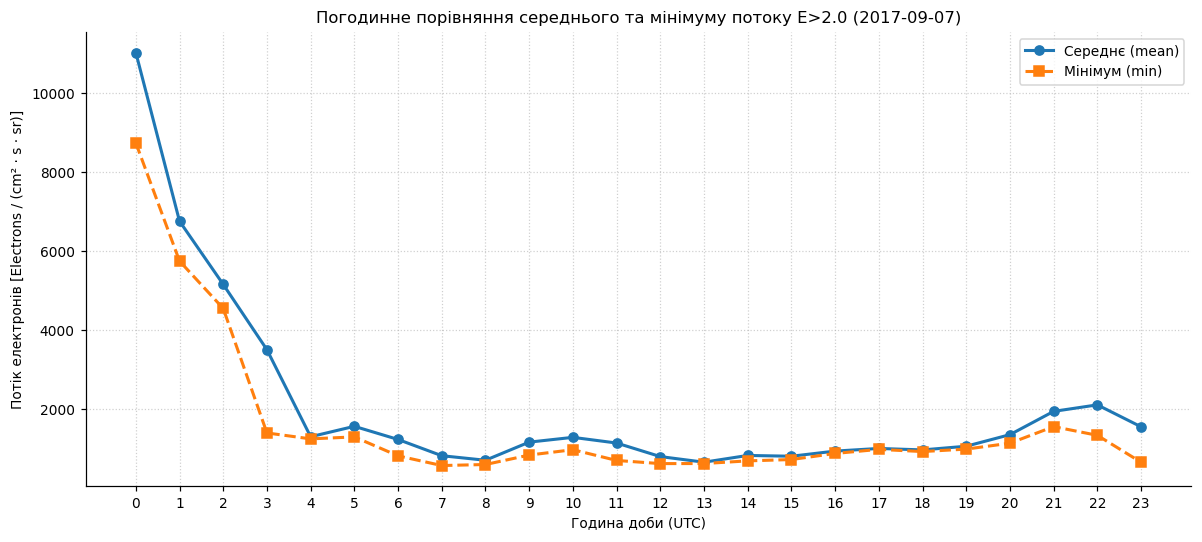

In [15]:
# ВАШ КОД
# 1. Фільтруємо одну добу з уже готової зведеної таблиці A_hourly
selected_day = "2017-09-07"
day_mask = (A_hourly["ts"] >= f"{selected_day} 00:00:00") & (
    A_hourly["ts"] <= f"{selected_day} 23:59:59"
)
df_day = A_hourly[day_mask]

# 2. Побудова графіка для потоку E>2.0 (мінімум + середнє)
plt.figure(figsize=(11, 5))

# Використовуємо .dt.hour для отримання годин зі стовпця ts
plt.plot(
    df_day["ts"].dt.hour,
    df_day["E_gt_2_0_mean"],
    label="Середнє (mean)",
    marker="o",
    linewidth=2,
    color="tab:blue",
)
plt.plot(
    df_day["ts"].dt.hour,
    df_day["E_gt_2_0_min"],
    label="Мінімум (min)",
    marker="s",
    linestyle="--",
    linewidth=2,
    color="tab:orange",
)

plt.title(
    f"Погодинне порівняння середнього та мінімуму потоку E>2.0 ({selected_day})"
)
plt.xlabel("Година доби (UTC)")
plt.ylabel("Потік електронів [Electrons / (cm² · s · sr)]")
plt.xticks(range(0, 24))
plt.grid(True, linestyle=":", alpha=0.6)
plt.legend()
plt.tight_layout()
plt.show()

**Відповідь 4.2:** *(чим відрізняються криві та коли це важливо)*

Крива мінімального значення показує найменший з 12 замірів за годину, тоді ж як крива середнього показує середнє від усіх 12 замірів за годину. В години різких змін може зафіксуватись низьке значення, яке не буде відображати реальний стан речей впродовж годлини

### Завдання 4.3
Об'єднайте три таблиці в одну — назвіть її `M`. Виведіть її розмір і всі рядки,
у яких є хоча б один пропуск.

**Зверніть увагу:** таблиці закінчуються не в один і той самий момент. Тому результат
залежить від того, який тип об'єднання ви оберете (`how='inner'` чи `how='outer'`).
Спробуйте обидва, подивіться, чим відрізняється кількість рядків, і поясніть свій вибір.

In [16]:
B_clean = B[["ts", "Radio_Flux_10_7"]].copy()


hourly_range_B = pd.date_range(
    start="2017-08-28 00:00:00", end="2017-09-21 23:00:00", freq="1h"
)

B_hourly = (
    B_clean.set_index("ts")
    .reindex(hourly_range_B)
    .ffill()
    .reset_index()
    .rename(columns={"index": "ts"})
)

C_clean = C[["ts", "Proton_Speed", "Proton_Density"]].copy()

M_inner = A_hourly.merge(B_hourly, on="ts", how="inner").merge(
    C_clean, on="ts", how="inner"
)

M_outer = A_hourly.merge(B_hourly, on="ts", how="outer").merge(
    C_clean, on="ts", how="outer"
)

print(f"Розмір M (inner): {M_inner.shape}")
print(f"Розмір M (outer): {M_outer.shape}")


M = M_inner.copy()

missing_rows1 = M[M.isna().any(axis=1)]
print(f"\nКількість рядків з хоча б одним NaN у таблиці M: {len(missing_rows1)}")
display(missing_rows1)
missing_rows2 = M_outer[M_outer.isna().any(axis=1)]
print(f"\nКількість рядків з хоча б одним NaN у таблиці M: {len(missing_rows2)}")
display(missing_rows2)


Розмір M (inner): (600, 36)
Розмір M (outer): (601, 36)

Кількість рядків з хоча б одним NaN у таблиці M: 8


,ts,P_gt_1_mean,P_gt_1_max,P_gt_1_min,P_gt_1_median,P_gt_5_mean,P_gt_5_max,P_gt_5_min,P_gt_5_median,P_gt_10_mean,P_gt_10_max,P_gt_10_min,P_gt_10_median,P_gt_30_mean,P_gt_30_max,P_gt_30_min,P_gt_30_median,P_gt_50_mean,P_gt_50_max,P_gt_50_min,P_gt_50_median,P_gt_100_mean,P_gt_100_max,P_gt_100_min,P_gt_100_median,E_gt_0_8_mean,E_gt_0_8_max,E_gt_0_8_min,E_gt_0_8_median,E_gt_2_0_mean,E_gt_2_0_max,E_gt_2_0_min,E_gt_2_0_median,Radio_Flux_10_7,Proton_Speed,Proton_Density
175,2017-09-04 07:00:00,6.465833,10.10,4.37,6.275,0.262083,0.593,0.159,0.2345,0.171500,0.294,0.121,0.1540,0.085483,0.145,0.0625,0.07080,0.068558,0.134,0.0508,0.05445,0.031717,0.0523,0.0257,0.02570,90600.000000,100000.0,82200.0,90000.0,7410.833333,8950.0,6150.0,7320.0,140.0,NaN,NaN
176,2017-09-04 08:00:00,4.010833,5.08,2.66,4.080,0.256000,0.432,0.168,0.2340,0.195833,0.336,0.123,0.1595,0.086625,0.145,0.0625,0.08310,0.070033,0.134,0.0508,0.05960,0.036492,0.0546,0.0257,0.03440,73483.333333,79300.0,66400.0,73250.0,5048.333333,5850.0,4120.0,5040.0,140.0,NaN,NaN
177,2017-09-04 09:00:00,3.268333,4.42,2.26,3.040,0.303417,0.518,0.197,0.2985,0.220333,0.302,0.160,0.2210,0.105925,0.162,0.0625,0.11100,0.081975,0.134,0.0508,0.07775,0.046483,0.0765,0.0257,0.04640,60475.000000,68500.0,55100.0,60300.0,3715.833333,4480.0,3120.0,3695.0,140.0,NaN,NaN
178,2017-09-04 10:00:00,3.179167,4.74,2.38,2.975,0.252167,0.372,0.171,0.2240,0.181833,0.280,0.123,0.1710,0.101900,0.150,0.0625,0.10600,0.081675,0.120,0.0508,0.08600,0.054125,0.0894,0.0257,0.05540,64383.333333,68400.0,61200.0,64000.0,4122.500000,4710.0,3810.0,4050.0,140.0,NaN,NaN
179,2017-09-04 11:00:00,5.274167,7.98,3.69,4.535,0.295083,0.657,0.160,0.2545,0.186917,0.276,0.123,0.1710,0.089525,0.166,0.0625,0.07205,0.063983,0.110,0.0508,0.05620,0.033633,0.0684,0.0257,0.02570,79933.333333,88200.0,67900.0,79900.0,6345.833333,7430.0,4790.0,6420.0,140.0,NaN,NaN
180,2017-09-04 12:00:00,2.965000,4.85,2.05,2.815,0.217750,0.428,0.159,0.1995,0.153500,0.239,0.121,0.1445,0.089217,0.179,0.0625,0.07860,0.071217,0.144,0.0508,0.06060,0.037233,0.0679,0.0257,0.02795,80516.666667,88700.0,74400.0,79500.0,6080.000000,7420.0,5330.0,6005.0,140.0,NaN,NaN
181,2017-09-04 13:00:00,3.061667,3.86,2.07,3.205,0.275833,0.551,0.159,0.2725,0.192833,0.329,0.121,0.1925,0.104542,0.170,0.0625,0.10025,0.083783,0.159,0.0508,0.07655,0.041342,0.0611,0.0257,0.04025,76733.333333,85900.0,69800.0,75800.0,6015.833333,7540.0,4920.0,5875.0,140.0,NaN,NaN
182,2017-09-04 14:00:00,7.279167,10.80,3.65,7.490,0.231333,0.409,0.159,0.1985,0.170583,0.313,0.121,0.1470,0.086508,0.178,0.0625,0.07860,0.070667,0.166,0.0508,0.05655,0.037375,0.0888,0.0257,0.02570,83025.000000,90200.0,77100.0,82050.0,8552.500000,10500.0,7070.0,8350.0,140.0,NaN,NaN



Кількість рядків з хоча б одним NaN у таблиці M: 9


,ts,P_gt_1_mean,P_gt_1_max,P_gt_1_min,P_gt_1_median,P_gt_5_mean,P_gt_5_max,P_gt_5_min,P_gt_5_median,P_gt_10_mean,P_gt_10_max,P_gt_10_min,P_gt_10_median,P_gt_30_mean,P_gt_30_max,P_gt_30_min,P_gt_30_median,P_gt_50_mean,P_gt_50_max,P_gt_50_min,P_gt_50_median,P_gt_100_mean,P_gt_100_max,P_gt_100_min,P_gt_100_median,E_gt_0_8_mean,E_gt_0_8_max,E_gt_0_8_min,E_gt_0_8_median,E_gt_2_0_mean,E_gt_2_0_max,E_gt_2_0_min,E_gt_2_0_median,Radio_Flux_10_7,Proton_Speed,Proton_Density
175,2017-09-04 07:00:00,6.465833,10.10,4.37,6.275,0.262083,0.593,0.159,0.2345,0.171500,0.294,0.121,0.1540,0.085483,0.145,0.0625,0.07080,0.068558,0.134,0.0508,0.05445,0.031717,0.0523,0.0257,0.02570,90600.000000,100000.0,82200.0,90000.0,7410.833333,8950.0,6150.0,7320.0,140.0,NaN,NaN
176,2017-09-04 08:00:00,4.010833,5.08,2.66,4.080,0.256000,0.432,0.168,0.2340,0.195833,0.336,0.123,0.1595,0.086625,0.145,0.0625,0.08310,0.070033,0.134,0.0508,0.05960,0.036492,0.0546,0.0257,0.03440,73483.333333,79300.0,66400.0,73250.0,5048.333333,5850.0,4120.0,5040.0,140.0,NaN,NaN
177,2017-09-04 09:00:00,3.268333,4.42,2.26,3.040,0.303417,0.518,0.197,0.2985,0.220333,0.302,0.160,0.2210,0.105925,0.162,0.0625,0.11100,0.081975,0.134,0.0508,0.07775,0.046483,0.0765,0.0257,0.04640,60475.000000,68500.0,55100.0,60300.0,3715.833333,4480.0,3120.0,3695.0,140.0,NaN,NaN
178,2017-09-04 10:00:00,3.179167,4.74,2.38,2.975,0.252167,0.372,0.171,0.2240,0.181833,0.280,0.123,0.1710,0.101900,0.150,0.0625,0.10600,0.081675,0.120,0.0508,0.08600,0.054125,0.0894,0.0257,0.05540,64383.333333,68400.0,61200.0,64000.0,4122.500000,4710.0,3810.0,4050.0,140.0,NaN,NaN
179,2017-09-04 11:00:00,5.274167,7.98,3.69,4.535,0.295083,0.657,0.160,0.2545,0.186917,0.276,0.123,0.1710,0.089525,0.166,0.0625,0.07205,0.063983,0.110,0.0508,0.05620,0.033633,0.0684,0.0257,0.02570,79933.333333,88200.0,67900.0,79900.0,6345.833333,7430.0,4790.0,6420.0,140.0,NaN,NaN
180,2017-09-04 12:00:00,2.965000,4.85,2.05,2.815,0.217750,0.428,0.159,0.1995,0.153500,0.239,0.121,0.1445,0.089217,0.179,0.0625,0.07860,0.071217,0.144,0.0508,0.06060,0.037233,0.0679,0.0257,0.02795,80516.666667,88700.0,74400.0,79500.0,6080.000000,7420.0,5330.0,6005.0,140.0,NaN,NaN
181,2017-09-04 13:00:00,3.061667,3.86,2.07,3.205,0.275833,0.551,0.159,0.2725,0.192833,0.329,0.121,0.1925,0.104542,0.170,0.0625,0.10025,0.083783,0.159,0.0508,0.07655,0.041342,0.0611,0.0257,0.04025,76733.333333,85900.0,69800.0,75800.0,6015.833333,7540.0,4920.0,5875.0,140.0,NaN,NaN
182,2017-09-04 14:00:00,7.279167,10.80,3.65,7.490,0.231333,0.409,0.159,0.1985,0.170583,0.313,0.121,0.1470,0.086508,0.178,0.0625,0.07860,0.070667,0.166,0.0508,0.05655,0.037375,0.0888,0.0257,0.02570,83025.000000,90200.0,77100.0,82050.0,8552.500000,10500.0,7070.0,8350.0,140.0,NaN,NaN
600,2017-09-22 00:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,381.0,1.0


**Відповідь 4.3:** *(який тип об'єднання обрано, скільки рядків дає кожен і чому)*

Inner join повертає лише перетин часових інтервалів (або значинь по яких об'єднуються таблиці), а outer join повне об'єднання таблиць. В Таблиці C є останнє спостереження за 00:00, тоді як в A і B спостереження завершується в 23:00, в наслідок чого outer join дає нам 601 запис з відсутніми замірами в таблицях A і B в останньому записі. Для більш зручної взаємодії між таблицями надалі, використовуєм inner join

### Завдання 4.4 — поділ на групи
Щоб далі було що з чим порівнювати, поділіть години на три групи за значенням
**максимуму потоку P>10 за годину**:

| Група | Умова |
|---|---|
| `тиха` | менше 10 |
| `активна` | від 10 до 1000 |
| `дуже активна` | 1000 і більше |

Додайте до `M` стовпець `група` і виведіть, скільки годин потрапило в кожну.

> Це не вигадані числа: саме такі пороги використовує метеослужба космічної погоди
> NOAA. Чому вони саме такі — питання не сьогоднішньої роботи.

In [17]:

bins = [-np.inf, 10, 1000, np.inf]
labels = ["тиха", "активна", "дуже активна"]

M["група"] = pd.cut(
    M["P_gt_10_max"], bins=bins, labels=labels, right=False
).astype(str)

group_counts = M["група"].value_counts()
print(group_counts)

група
тиха            411
активна         171
дуже активна     18
Name: count, dtype: int64


**Самоперевірка етапу 4.**

In [18]:
assert M is not None, 'таблиця M не побудована'
assert 'ts' in M.columns, 'у таблиці M потрібен стовпець ts'
assert 'група' in M.columns, 'у таблиці M потрібен стовпець «група»'
assert 590 <= len(M) <= 605, 'очікується близько 600 рядків, а є %d — перевірте об’єднання' % len(M)
print('Етап 4 пройдено:', len(M), 'рядків')

Етап 4 пройдено: 600 рядків


---
# Етап 5. П'ять графіків — п'ять питань

Графік будується як **відповідь на питання**, а не «щоб був».

**Вимоги до кожного графіка:**

* підписані обидві осі, з одиницями вимірювання;
* заголовок;
* під графіком, у текстовій клітинці, — **одне речення про дані**.
  Не «на графіку зображено потік протонів», а твердження на кшталт
  «більшість годин потік не перевищує 60, але кілька годин дають значення у сотні разів більші».

> Не кожне питання має відповідь «так, зв'язок є». Якщо на графіку нічого не видно —
> так і напишіть. Відсутність зв'язку — це теж результат, і чесно про неї написати
> важливіше, ніж підбирати ракурс, у якому «щось наче проглядається».

### Графік 1. Як розподілені значення вашого потоку?
Побудуйте гістограму вашого потоку (середнє за годину). Порахуйте окремо середнє
й медіану цього стовпця.

Якщо гістограма вийде нечитабельною — стовпчик біля нуля і порожньо далі — не
залишайте так. Спробуйте побудувати гістограму від логарифма значень
(`np.log10`) і подивіться, що зміниться.

**Питання:** чому середнє й медіана так сильно відрізняються?

Середнє: 11397.05
Медіана: 4338.75


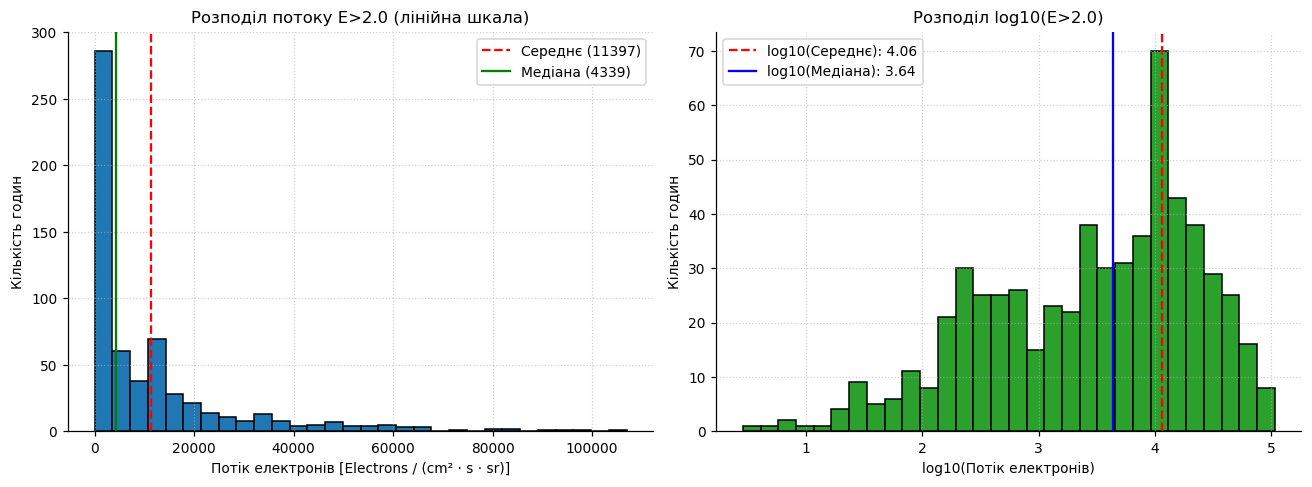

In [19]:

flow_col = "E_gt_2_0_mean"
mean_val = M[flow_col].mean()
median_val = M[flow_col].median()

print(f"Середнє: {mean_val:.2f}")
print(f"Медіана: {median_val:.2f}")

fig, ax = plt.subplots(1, 2, figsize=(12, 4.5))

ax[0].hist(M[flow_col].dropna(), bins=30, color="#1f77b4", edgecolor="black")
ax[0].axvline(
    mean_val,
    color="red",
    linestyle="--",
    linewidth=1.5,
    label=f"Середнє ({mean_val:.0f})",
)
ax[0].axvline(
    median_val,
    color="green",
    linestyle="-",
    linewidth=1.5,
    label=f"Медіана ({median_val:.0f})",
)
ax[0].set_title("Розподіл потоку E>2.0 (лінійна шкала)")
ax[0].set_xlabel("Потік електронів [Electrons / (cm² · s · sr)]")
ax[0].set_ylabel("Кількість годин")
ax[0].legend()
ax[0].grid(True, linestyle=":", alpha=0.6)

log_data = np.log10(M[flow_col].dropna().loc[lambda x: x > 0])
ax[1].hist(log_data, bins=30, color="#2ca02c", edgecolor="black")
ax[1].axvline(
    np.log10(mean_val),
    color="red",
    linestyle="--",
    linewidth=1.5,
    label=f"log10(Середнє): {np.log10(mean_val):.2f}",
)
ax[1].axvline(
    np.log10(median_val),
    color="blue",
    linestyle="-",
    linewidth=1.5,
    label=f"log10(Медіана): {np.log10(median_val):.2f}",
)
ax[1].set_title("Розподіл log10(E>2.0)")
ax[1].set_xlabel("log10(Потік електронів)")
ax[1].set_ylabel("Кількість годин")
ax[1].legend()
ax[1].grid(True, linestyle=":", alpha=0.6)

plt.tight_layout()
plt.show()

**Висновок:**

Розподіл потоку електронів має екстремальну правобічну асиметрію: більшість часу потік залишається фоновим (медіана складає 4339), проте нечисленні спалахи сонячної бурі перевищують 100000, що зміщує середнє арифметичне (11397) майже у 2.6 раза вище за медіану. З цього можна зробити висновок, що на метрику середнього значення не варто опиратись, оскільки він не відображає справжньої ситуації. Логарифм в зображеному графіку переводить абсолютні числа в порядки величин (показники степеня десятки)

### Графік 2. Чи відрізняється швидкість вітру між групами годин?
Побудуйте діаграму розмаху (`boxplot`) швидкості сонячного вітру окремо для кожної
групи з завдання 4.4.

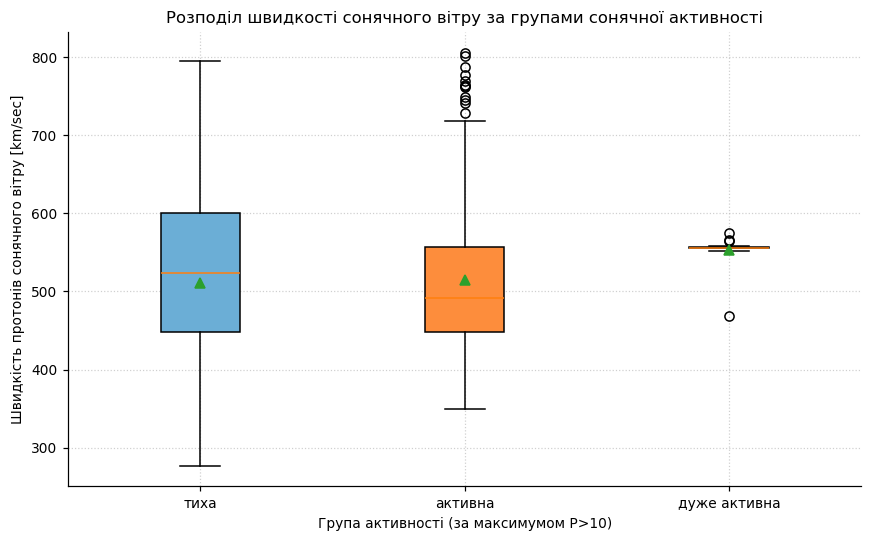

In [20]:
# ВАШ КОД

groups = ["тиха", "активна", "дуже активна"]
data_to_plot = [
    M.loc[M["група"] == g, "Proton_Speed"].dropna() for g in groups
]

plt.figure(figsize=(8, 5))
box = plt.boxplot(
    data_to_plot, tick_labels=groups, patch_artist=True, showmeans=True
)

colors = ["#6baed6", "#fd8d3c", "#e6550d"]
for patch, color in zip(box["boxes"], colors):
    patch.set_facecolor(color)

plt.title("Розподіл швидкості сонячного вітру за групами сонячної активності")
plt.xlabel("Група активності (за максимумом P>10)")
plt.ylabel("Швидкість протонів сонячного вітру [km/sec]")
plt.grid(True, linestyle=":", alpha=0.6)
plt.tight_layout()
plt.show()

**Висновок:**

Медіанна швидкість сонячного вітру є порівнянною в усіх трьох групах і становить приблизно 500–550 км/с, однак у періоди «тихих» та «активних» годин спостерігається значний розкид від приблизно 250 до 800 км/с, тоді як у фазі «дуже активних» годин швидкість вітру стабільно утримується у вузькому підвищеному діапазоні 470-575 км/с. З цього можемо взяти за висновок, що швидкість протонів сонячного вітру не є показнком наявності чи відсутності радіаційного шторму.

### Графік 3. Чи пов'язані змінні вашої пари?
Побудуйте діаграму розсіювання для пари з вашого завдання. Порахуйте коефіцієнт
кореляції між ними.

Коефіцієнт кореляції Пірсона: 0.0593


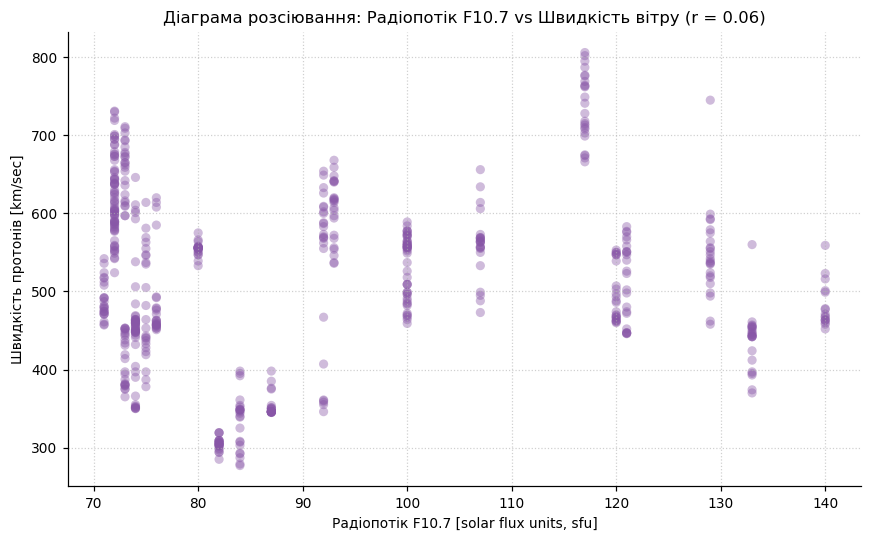

In [21]:

corr_val = M[["Radio_Flux_10_7", "Proton_Speed"]].dropna().corr().iloc[0, 1]
print(f"Коефіцієнт кореляції Пірсона: {corr_val:.4f}")

plt.figure(figsize=(8, 5))
plt.scatter(
    M["Radio_Flux_10_7"],
    M["Proton_Speed"],
    alpha=0.4,
    color="#8856a7",
    edgecolors="none",
)
plt.title(
    f"Діаграма розсіювання: Радіопотік F10.7 vs Швидкість вітру (r = {corr_val:.2f})"
)
plt.xlabel("Радіопотік F10.7 [solar flux units, sfu]")
plt.ylabel("Швидкість протонів [km/sec]")
plt.grid(True, linestyle=":", alpha=0.6)
plt.tight_layout()
plt.show()

**Висновок:**

Між добовим радіопотоком F10.7 та швидкістю сонячного вітру лінійний зв'язок практично відсутній, r = 0.06. Точки на діаграмі розсіювання розподілені хмарою, що свідчить про відсутність якоїсь вираженої кореляції.

### Графік 4. Скільки годин у кожній групі?
Побудуйте стовпчикову діаграму кількості годин за групами. Підпишіть кожен стовпчик
кількістю годин і відсотком від загальної кількості.

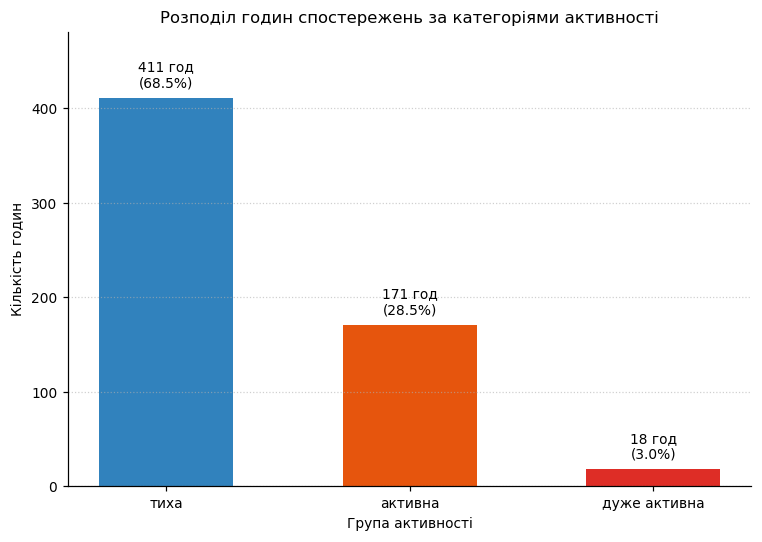

In [22]:
# ВАШ КОД

group_order = ["тиха", "активна", "дуже активна"]
counts = M["група"].value_counts()[group_order]
percentages = counts / len(M) * 100

plt.figure(figsize=(7, 5))
bars = plt.bar(
    group_order, counts, color=["#3182bd", "#e6550d", "#de2d26"], width=0.55
)

for bar, count, pct in zip(bars, counts, percentages):
    yval = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        yval + 8,
        f"{count} год\n({pct:.1f}%)",
        ha="center",
        va="bottom",
        fontsize=9,
    )

plt.title("Розподіл годин спостережень за категоріями активності")
plt.xlabel("Група активності")
plt.ylabel("Кількість годин")
plt.ylim(0, max(counts) + 70)
plt.grid(axis="y", linestyle=":", alpha=0.6)
plt.tight_layout()
plt.show()

**Висновок:**
Протягом спостережень переважали години тихої групи (411 годин, або 68.5% часу), до активної групи належала 171 година (28.5%), а дуже активна група містила лише 18 годин що становить лише 3.0%. З такого розподілу можемо зробити висновок, що більшість часу сонячне опромінення не є сильним, а критичні його показники є доволі рідкісними.

### Графік 5. Як усе це виглядало в часі?
Побудуйте лінійний графік максимуму потоку P>10 за годину за весь період спостережень.

Якщо крива виявиться нечитабельною — згадайте, що допомогло в графіку 1.

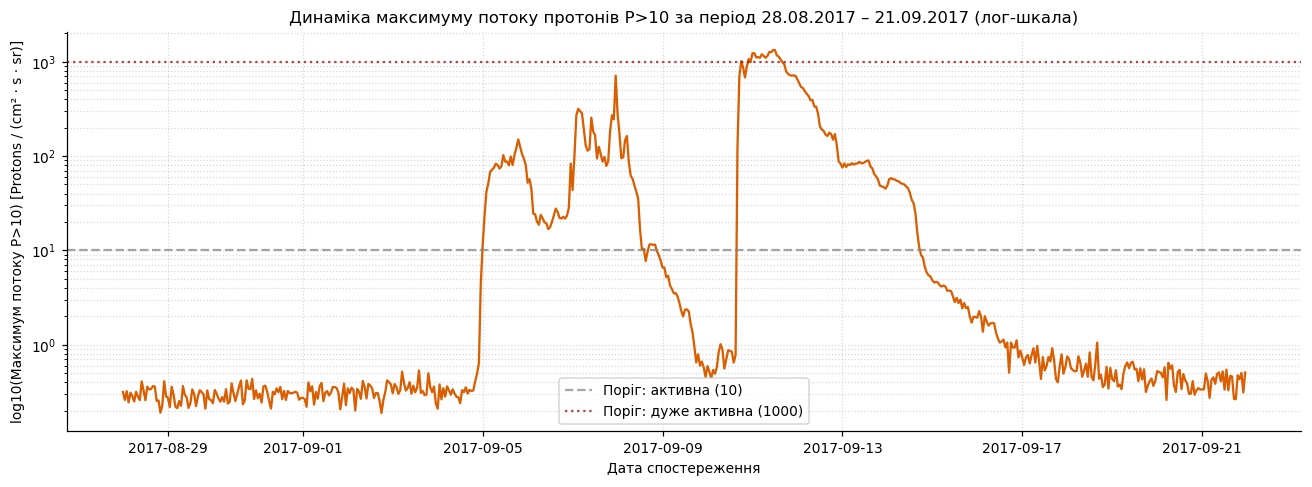

In [23]:
# ВАШ КОД

plt.figure(figsize=(12, 4.5))
plt.plot(M["ts"], M["P_gt_10_max"], color="#d95f02", linewidth=1.5)
plt.yscale("log")

# Допоміжні лінії меж груп
plt.axhline(10, color="gray", linestyle="--", alpha=0.7, label="Поріг: активна (10)")
plt.axhline(
    1000,
    color="darkred",
    linestyle=":",
    alpha=0.7,
    label="Поріг: дуже активна (1000)",
)

plt.title(
    "Динаміка максимуму потоку протонів P>10 за період 28.08.2017 – 21.09.2017 (лог-шкала)"
)
plt.xlabel("Дата спостереження")
plt.ylabel("log10(Максимум потоку P>10) [Protons / (cm² · s · sr)]")
plt.legend()
plt.grid(True, which="both", linestyle=":", alpha=0.5)
plt.tight_layout()
plt.show()

**Висновок:**

З цього графіку ми бачимо, що радіаційний фон спадає повільніше за зростання, також має відносно довгу тривалість високому діапазоні перед спаданням, а скачки є доволі різкими

---
# Етап 6. Два графіки одних і тих самих даних

Нижче побудовано два графіки. Дані в них **одні й ті самі** — це той самий стовпець
з тієї самої таблиці, жодне число не змінено.

Виконайте клітинку й подивіться на обидва.

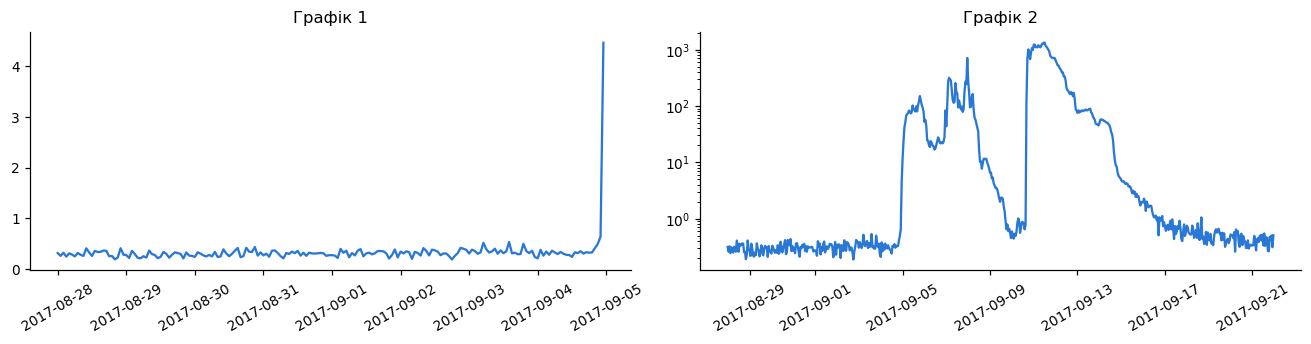

In [24]:
СТОВПЕЦЬ = 'P_gt_10_max'   # <- впишіть назву свого стовпця з МАКСИМУМОМ P>10 за годину

вікно = M[(M['ts'] >= '2017-08-28') & (M['ts'] < '2017-09-05')]

fig, ax = plt.subplots(1, 2, figsize=(12, 3.2))

ax[0].plot(вікно['ts'], вікно[СТОВПЕЦЬ], color='#2a78d6')
ax[0].set_title('Графік 1')
ax[0].tick_params(axis='x', rotation=30)

ax[1].plot(M['ts'], M[СТОВПЕЦЬ], color='#2a78d6')
ax[1].set_yscale('log')
ax[1].set_title('Графік 2')
ax[1].tick_params(axis='x', rotation=30)

fig.tight_layout()
plt.show()

### Завдання 6.1
Дайте відповідь на три питання:

1. Який висновок про космічну погоду у вересні 2017 року зробить людина, яка бачила
   **тільки перший** графік?
2. Який висновок зробить людина, яка бачила **тільки другий**?
3. Чим ці два графіки відрізняються між собою? Назвіть **дві** відмінності —
   вони обидві є в коді вище.

*Жодне число в обох графіках не підроблене. Різниця виникла тільки через те,
як їх побудували.*

**Відповідь 6.1:**

1. Висновок з першого графіка: Людина, що бачила лише перший графік, зробить висновок, що погода на початку вересня мала спокійний поток протонів, за виключанням маленького сплеску 5 вересня, проте не матиме ніякого уявлення про те яким великим був сплеск насправді, де він закінчився і як довго він тривав. Імовірно людина не вважатиме це значним сплеском взагалі. Так само людина не матиме жодного уявлення про погоду в решті місяця.
2. Висновок з другого графіка: Людина побачить реальну картину з катастрофічним сплеском потоку частинок на 4 порядки величини в районі 7–10 вересня, що свідчить про потужну геомагнітну подію.
3. Дві відмінності між ними: на першому графіку шкала лінійна, а на другому застосовано логорифмічну шкалу (ax[1].set_yscale('log')), що дозволяє одночасно бачити як слабкий фоновий шум, так і піки понад 1000 одиниць. Також пеший графік обрізаний по датах спостереження, а на 2 нанесено всі дані.


### Завдання 6.2
Уявіть, що вам потрібно **одним графіком** чесно показати, що відбувалося в цьому
періоді. Побудуйте його самі й підпишіть заголовком, який формулює висновок.

Поясніть у клітинці нижче, чому ви обрали саме такий вигляд.

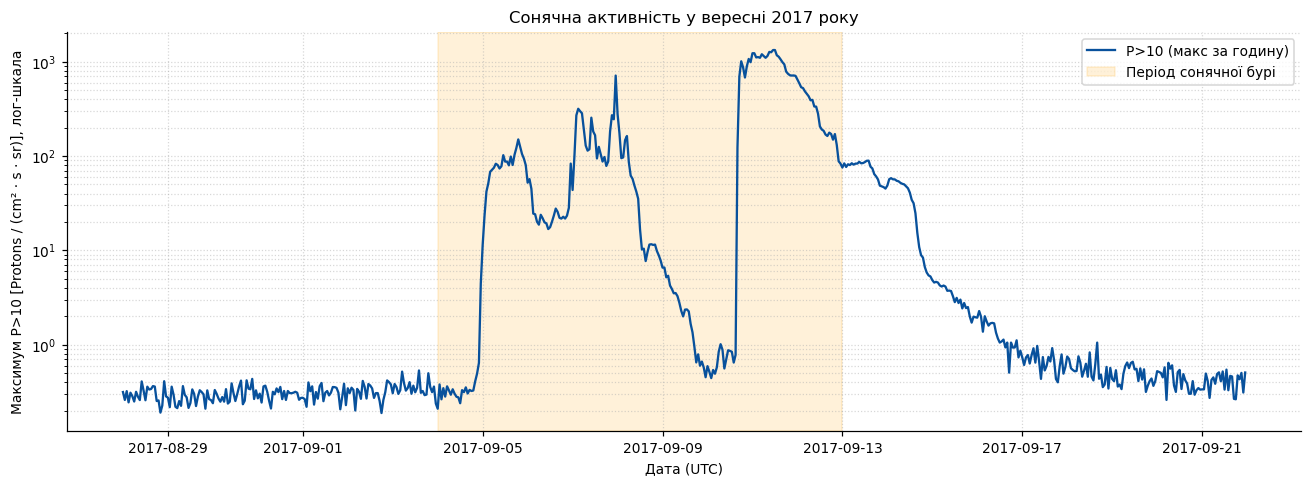

In [25]:
# ВАШ КОД
plt.figure(figsize=(12, 4.5))
plt.plot(
    M["ts"],
    M["P_gt_10_max"],
    color="#08519c",
    linewidth=1.5,
    label="P>10 (макс за годину)",
)
plt.yscale("log")

plt.axvspan(
    pd.to_datetime("2017-09-04"),
    pd.to_datetime("2017-09-13"),
    color="orange",
    alpha=0.15,
    label="Період сонячної бурі",
)
plt.title(
    "Сонячна активність у вересні 2017 року"
)
plt.xlabel("Дата (UTC)")
plt.ylabel("Максимум P>10 [Protons / (cm² · s · sr)], лог-шкала")
plt.legend()
plt.grid(True, which="both", linestyle=":", alpha=0.5)
plt.tight_layout()
plt.show()

**Відповідь 6.2:** *(чому ви побудували графік саме так)*

Обрано повний часовий діапазон у поєднанні з логарифмічною віссю $Y$, оскільки лінійна шкала перетворює фонові значення першого тижня на невидиму лінію вздовж нуля, а скорочення вікна спотворює висновки; логарифмічний масштаб на всій вибірці дозволяє чесно показати і фоновий стан, і справжній чотирикратний порядок зростання шторму. Також позначено, що сплеск потоку протонів позначає період сонячної бурі.

---
# Етап 7. Три спостереження та ваше питання

### Завдання 7.1
Запишіть **три спостереження** про ці дані, які ви зробили під час роботи.

Спостереження — це твердження, яке спирається на конкретне число або графік з вашого
ноутбука. Не «дані цікаві», а, наприклад, «максимальне значення потоку у 2000 разів
більше за медіанне, і всі такі години припадають на одні й ті самі три доби».

Для кожного вкажіть, **де саме** у вашій роботі його видно.

**Спостереження 1:**
Медіана краще відображує середній потік електронів, оскільки середнє значення потоку спотворюється малочисельними даними з великим значенням. Це видно на 1 графіку 5 етапу

**Спостереження 2:**
Середня швидкість сонячного вітру та показник сонячного радіовипромінювання F10.7 мають практично нульову лінійну кореляцію r = 0.06, що свідчить про те, що сплески сонячного випромінювання та швидкість потоку плазми біля Землі не пов'язані прямою синхронною залежністю, що видно на 3 графіку 5 етапу.

**Спостереження 3:**
Прилад SOHO CELIAS мав тривалий безперервний збій реєстрації сонячного вітру тривалістю рівно 8 годин підряд (з 07:00 до 14:00 4 вересня 2017 року), коли замість фізичних даних передавався технічний маркер -1 (видно в завданнях 3.2 та 4.3)



### Завдання 7.2 — ваше індивідуальне питання
Дайте відповідь на додаткове питання зі свого завдання. Відповідь має спиратися
на обчислення: наведіть код і результат, а потім сформулюйте висновок словами.

In [26]:
# ВАШ КОД
# 1-й тиждень: 2017-08-28 00:00:00 до 2017-09-03 23:59:59 (перші 7 діб)
# 2-й тиждень: 2017-09-04 00:00:00 до 2017-09-10 23:59:59 (наступні 7 діб)
mask_w1 = (A["ts"] >= "2017-08-28 00:00:00") & (A["ts"] < "2017-09-04 00:00:00")
mask_w2 = (A["ts"] >= "2017-09-04 00:00:00") & (A["ts"] < "2017-09-11 00:00:00")

med_w1 = A.loc[mask_w1, "E_gt_2_0"].median()
med_w2 = A.loc[mask_w2, "E_gt_2_0"].median()
ratio = med_w2 / med_w1

print(f"Медіана потоку E>2.0 за 1-й тиждень: {med_w1:.1f}")
print(f"Медіана потоку E>2.0 за 2-й тиждень: {med_w2:.1f}")
print(f"Відношення (W2 / W1): {ratio:.2f}")

Медіана потоку E>2.0 за 1-й тиждень: 452.0
Медіана потоку E>2.0 за 2-й тиждень: 6790.0
Відношення (W2 / W1): 15.02


**Відповідь 7.2:**

Медіана потоку електронів за 1 тиждень складає 452 Elctrons/(cm^2 * s * sr). За другий - 6790 Elctrons/(cm^2 * s * sr). Медіана за другий тиждень зросла у 15.02 разів, що безпосередньо спричинено початком потужного циклу сонячних спалахів і геомагнітної бурі з 5 вересня.

---
# Етап 8. Декларація про використання інструментів штучного інтелекту

Користуватися мовними моделями під час виконання цієї роботи **дозволено**. Це
нормальна інженерна практика, і курс про штучний інтелект не має підстав її забороняти.

Обов'язковою є прозорість: ви вказуєте, де саме і як скористалися інструментом —
так само, як у науковій статті вказують використане програмне забезпечення.
**Задекларована допомога порушенням не є.**

Порушенням є інше: здати роботу, яку ви не можете пояснити. На захисті вас попросять
показати конкретний рядок вашого коду, пояснити, чому він саме такий, і внести в нього
невелику зміну на місці. Якщо код згенеровано, але ви його розумієте — робота
зарахована. Якщо не розумієте — не зарахована, незалежно від того, хто його написав.

### Завдання 8.1
Заповніть словник. Для кожного етапу оберіть одне з формулювань:

* `'ні'` — інструментами ШІ не користувався;
* `'синтаксис'` — питав про назву функції або синтаксис, код писав сам;
* `'код, перевірено'` — код згенеровано, я його прочитав, перевірив і розумію;
* `'текст, перероблено'` — згенеровано чернетку тексту, яку я переписав по суті;
* `'текст, як є'` — згенерований текст залишено майже без змін.

Останній варіант не заборонений, але прямо впливає на оцінку: бали ставляться
за висновки, а не за наявність абзацу.

In [27]:
ІНСТРУМЕНТИ_ШІ = "Gemini"

ДЕКЛАРАЦІЯ = {
    "етапи 1–2, читання файлу та розбір таблиць": "синтаксис",
    "етап 3, паспорт даних і дивні значення": "синтаксис",
    "етап 4, об’єднання таблиць": "код, перевірено",
    "етап 5, побудова графіків": "код, перевірено",
    "етап 5, формулювання висновків": "текст, перероблено",
    "етапи 6–7, порівняння графіків і спостереження": "текст, перероблено",
}

ЩО_ПЕРЕВІРЕНО = (
    "Перевірив та виправив логіку об'єднання: на 24 години була розтягнута не та таблиця "
    "Самостійно знайшов причину, чому в M_outer відображалося 8 пропусків замість 9 (повторний вивід старої змінної missing_rows). "
    "Знайшов помилку AttributeError для RangeIndex при виклику .hour та замінив на dt.hour зі стовпця ts. "
    "Перевірив поведінку boxplot для 3-ї групи: з'ясував, що тонка лінія зумовлена замалим розмахом. "
    "Всі висновки і відповіді переписані і відформатовани з простого опису проробленого завдання до аналітичних висновків."
)


ПІДТВЕРДЖУЮ = True

In [28]:
# --- перевірка повноти декларації: клітинку не редагувати --------------------
ДОЗВОЛЕНІ = {'ні', 'синтаксис', 'код, перевірено', 'текст, перероблено', 'текст, як є'}

assert ІНСТРУМЕНТИ_ШІ.strip(), 'Вкажіть інструменти або напишіть «не використовував»'
порожні = [k for k, v in ДЕКЛАРАЦІЯ.items() if not str(v).strip()]
assert not порожні, 'Не заповнено пункти декларації: %s' % '; '.join(порожні)
чужі = {v for v in ДЕКЛАРАЦІЯ.values() if v not in ДОЗВОЛЕНІ}
assert not чужі, 'Недопустимі значення: %s. Оберіть з переліку вище.' % ', '.join(sorted(чужі))
assert len(ЩО_ПЕРЕВІРЕНО.strip()) >= 120, ('Опишіть конкретніше, що саме ви перевірили '
                                           '(зараз %d символів, потрібно щонайменше 120)'
                                           % len(ЩО_ПЕРЕВІРЕНО.strip()))
assert ПІДТВЕРДЖУЮ is True, 'Підтвердьте, що можете пояснити власний код на захисті'

print('ДЕКЛАРАЦІЯ ПРО ВИКОРИСТАННЯ ІНСТРУМЕНТІВ ШІ')
print('=' * 78)
print('%-46s %s' % ('автор:', ПІБ))
print('%-46s %s' % ('інструменти:', ІНСТРУМЕНТИ_ШІ))
print('-' * 78)
for k, v in ДЕКЛАРАЦІЯ.items():
    print('%-46s %s' % (k + ':', v))
print('-' * 78)
print('перевірено автором:')
print(ЩО_ПЕРЕВІРЕНО)
print('=' * 78)
print('Автор підтверджує, що може пояснити кожен рядок коду під час захисту.')

ДЕКЛАРАЦІЯ ПРО ВИКОРИСТАННЯ ІНСТРУМЕНТІВ ШІ
автор:                                         Корнілов Артем Сергійович
інструменти:                                   Gemini
------------------------------------------------------------------------------
етапи 1–2, читання файлу та розбір таблиць:    синтаксис
етап 3, паспорт даних і дивні значення:        синтаксис
етап 4, об’єднання таблиць:                    код, перевірено
етап 5, побудова графіків:                     код, перевірено
етап 5, формулювання висновків:                текст, перероблено
етапи 6–7, порівняння графіків і спостереження: текст, перероблено
------------------------------------------------------------------------------
перевірено автором:
Перевірив та виправив логіку об'єднання: на 24 години була розтягнута не та таблиця Самостійно знайшов причину, чому в M_outer відображалося 8 пропусків замість 9 (повторний вивід старої змінної missing_rows). Знайшов помилку AttributeError для RangeIndex при виклику .hour та з

---
# Крок 9. Збереження результату та фінальна самоперевірка

Об'єднана таблиця знадобиться вам у лабораторних роботах № 3 і № 4 — збережіть її
й не втрачайте до кінця семестру.

In [29]:
M.to_csv('master_hourly.csv', index=False)
print('збережено:', M.shape)

збережено: (600, 37)


In [30]:
# --- фінальна самоперевірка --------------------------------------------------
перевірки = {
    'ПІБ і варіант заповнено':        bool(ПІБ) and bool(ВАРІАНТ),
    'таблиця A (7200 рядків)':        len(A) == 7200,
    'таблиця B (25 рядків)':          len(B) == 25,
    'таблиця C (601 рядок)':          len(C) == 601,
    'таблиці об’єднано':              M is not None and 590 <= len(M) <= 605,
    'стовпець «група» є':             'група' in M.columns,
    'усі дати у 2017 році':           int(pd.to_datetime(M['ts']).dt.year.min()) == 2017,
    'декларацію заповнено':           bool(ІНСТРУМЕНТИ_ШІ.strip()) and ПІДТВЕРДЖУЮ is True,
}
for k, v in перевірки.items():
    print(('OK   ' if v else 'НЕ ОК') + '  ' + k)

if all(перевірки.values()):
    print('\nТехнічна частина роботи виконана.')
    print('Тепер переконайтеся, що заповнені ВСІ клітинки з відповідями та висновками,')
    print('і виконайте Kernel → Restart & Run All перед здачею.')

OK     ПІБ і варіант заповнено
OK     таблиця A (7200 рядків)
OK     таблиця B (25 рядків)
OK     таблиця C (601 рядок)
OK     таблиці об’єднано
OK     стовпець «група» є
OK     усі дати у 2017 році
OK     декларацію заповнено

Технічна частина роботи виконана.
Тепер переконайтеся, що заповнені ВСІ клітинки з відповідями та висновками,
і виконайте Kernel → Restart & Run All перед здачею.
